# Data Modelling - Time series forecasting

In this notebook we will perform a simple data modelling to forecast the solar production of the next day


## 1.0 Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load datasets
generation_df = pd.read_csv('../data/Plant_2_Generation_Data.csv')
weather_df = pd.read_csv('../data/Plant_2_Weather_Sensor_Data.csv')

# Convert DATE_TIME
generation_df['DATE_TIME'] = pd.to_datetime(generation_df['DATE_TIME'])
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

# Create DAY and TIME columns
generation_df['DAY'] = generation_df['DATE_TIME'].dt.date
generation_df['DAYTIME'] = generation_df['DATE_TIME'].dt.time

print(f"Generation data: {generation_df.shape}")
print(f"Unique inverters: {generation_df['SOURCE_KEY'].nunique()}")
print(f"Date range: {generation_df['DATE_TIME'].min()} to {generation_df['DATE_TIME'].max()}")

Generation data: (67698, 9)
Unique inverters: 22
Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00


## Step 2: Data Preparation

With our data understandig we discover that we have two cluster of inverter with different data completness. We want to perform the analysis on the cluster with a better data quality.

In [2]:
# Calculate data completeness
total_sample_per_day = 96
source_dataquality = generation_df.groupby(['DAY','SOURCE_KEY'])[['DAYTIME']].count().rename(columns={'DAYTIME': 'sample_completeness'})
source_dataquality['sample_completeness'] = round(source_dataquality['sample_completeness'] / total_sample_per_day * 100, 2)

# Create heatmap data
heatmap_data = source_dataquality.reset_index().pivot(index='SOURCE_KEY', columns='DAY', values='sample_completeness')

# Select SOURCE_KEYs with more than 98% average completeness
completeness_threshold = 98.0
source_avg_completeness = heatmap_data.mean(axis=1)
high_quality_sources = list(source_avg_completeness[source_avg_completeness > completeness_threshold].index)

print(f"High-quality sources: {len(high_quality_sources)} out of {len(source_avg_completeness)}")
print(f"Selected: {high_quality_sources}")

# Filter data
generation_df = generation_df[generation_df.SOURCE_KEY.isin(high_quality_sources)]
print(f"Filtered data shape: {generation_df.shape}")

High-quality sources: 12 out of 22
Selected: ['81aHJ1q11NBPMrL', '9kRcWv60rDACzjR', 'LYwnQax7tkwH5Cb', 'LlT2YUhhzqhg5Sw', 'PeE6FRyGXUgsRhN', 'V94E5Ben1TlhnDV', 'WcxssY2VbP4hApt', 'oZZkBaNadn6DNKz', 'q49J1IKaHRwDQnt', 'rrq4fwE8jgrTyWY', 'vOuJvMaM2sgwLmb', 'xoJJ8DcxJEcupym']
Filtered data shape: (39108, 9)


## Step 3: Time Series Forecasting with Prophet

We'll use Facebook Prophet to forecast DC_POWER at DAYTIME granularity, 1 day ahead, and perform backtesting.

In [3]:
# Import Prophet
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aggregate DC_POWER by DATE_TIME (sum across all inverters)
ts_data = generation_df.groupby('DATE_TIME')['DC_POWER'].sum().reset_index()
ts_data.columns = ['ds', 'y']  # Prophet requires 'ds' and 'y' column names

print(f"Time series data shape: {ts_data.shape}")
print(f"Date range: {ts_data['ds'].min()} to {ts_data['ds'].max()}")
print(f"\nFirst few rows:")
print(ts_data.head())

Importing plotly failed. Interactive plots will not work.


Time series data shape: (3259, 2)
Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00

First few rows:
                   ds    y
0 2020-05-15 00:00:00  0.0
1 2020-05-15 00:15:00  0.0
2 2020-05-15 00:30:00  0.0
3 2020-05-15 00:45:00  0.0
4 2020-05-15 01:00:00  0.0


In [4]:
# Prepare for backtesting: split data
# We'll use all data except the last day for training, and the last day for testing
unique_days = sorted(ts_data['ds'].dt.date.unique())
test_day = unique_days[-1]
train_days = unique_days[:-1]

print(f"Total days: {len(unique_days)}")
print(f"Training days: {len(train_days)} (from {train_days[0]} to {train_days[-1]})")
print(f"Test day: {test_day}")

# Split the data
train_data = ts_data[ts_data['ds'].dt.date.isin(train_days)]
test_data = ts_data[ts_data['ds'].dt.date == test_day]

print(f"\nTraining data: {len(train_data)} records")
print(f"Test data: {len(test_data)} records")

Total days: 34
Training days: 33 (from 2020-05-15 to 2020-06-16)
Test day: 2020-06-17

Training data: 3163 records
Test data: 96 records


In [5]:
# Train Prophet model with more rigid trend
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode='multiplicative',
    #changepoint_prior_scale=0.01  # Lower value = more rigid trend (default is 0.05)
)

print("Training Prophet model...")
model.fit(train_data)
print("Model training completed!")

17:35:25 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet model...


17:35:27 - cmdstanpy - INFO - Chain [1] done processing


Model training completed!


In [6]:
# Make predictions for the test day (1 day ahead)
future = model.make_future_dataframe(periods=len(test_data), freq='15min')
forecast = model.predict(future)

# Extract predictions for the test day
test_predictions = forecast[forecast['ds'].dt.date == test_day][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
test_predictions = test_predictions.merge(test_data, on='ds', how='inner')

print(f"Predictions generated: {len(test_predictions)} records")
print(f"\nSample predictions:")
print(test_predictions.head())

Predictions generated: 96 records

Sample predictions:
                   ds        yhat   yhat_lower   yhat_upper    y
0 2020-06-17 00:00:00 -303.346734 -2298.534162  1580.570777  0.0
1 2020-06-17 00:15:00 -305.836509 -2173.846538  1596.179661  0.0
2 2020-06-17 00:30:00 -278.022259 -2149.564731  1626.345459  0.0
3 2020-06-17 00:45:00 -222.297565 -2052.335009  1689.661331  0.0
4 2020-06-17 01:00:00 -143.755323 -1904.803144  1821.810972  0.0


In [7]:
# Evaluate test performance
mae = mean_absolute_error(test_predictions['y'], test_predictions['yhat'])
rmse = np.sqrt(mean_squared_error(test_predictions['y'], test_predictions['yhat']))
r2 = r2_score(test_predictions['y'], test_predictions['yhat'])

# Calculate MAPE (Mean Absolute Percentage Error)
# Only for non-zero actual values to avoid division by zero
non_zero_mask = test_predictions['y'] > 0
mape = np.mean(np.abs((test_predictions.loc[non_zero_mask, 'y'] - test_predictions.loc[non_zero_mask, 'yhat']) / 
                       test_predictions.loc[non_zero_mask, 'y'])) * 100

print("=" * 50)
print("TEST RESULTS - 1 DAY AHEAD FORECAST")
print("=" * 50)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print("=" * 50)

TEST RESULTS - 1 DAY AHEAD FORECAST
Mean Absolute Error (MAE): 1165.41
Root Mean Squared Error (RMSE): 1807.44
R² Score: 0.6172
Mean Absolute Percentage Error (MAPE): 117.30%


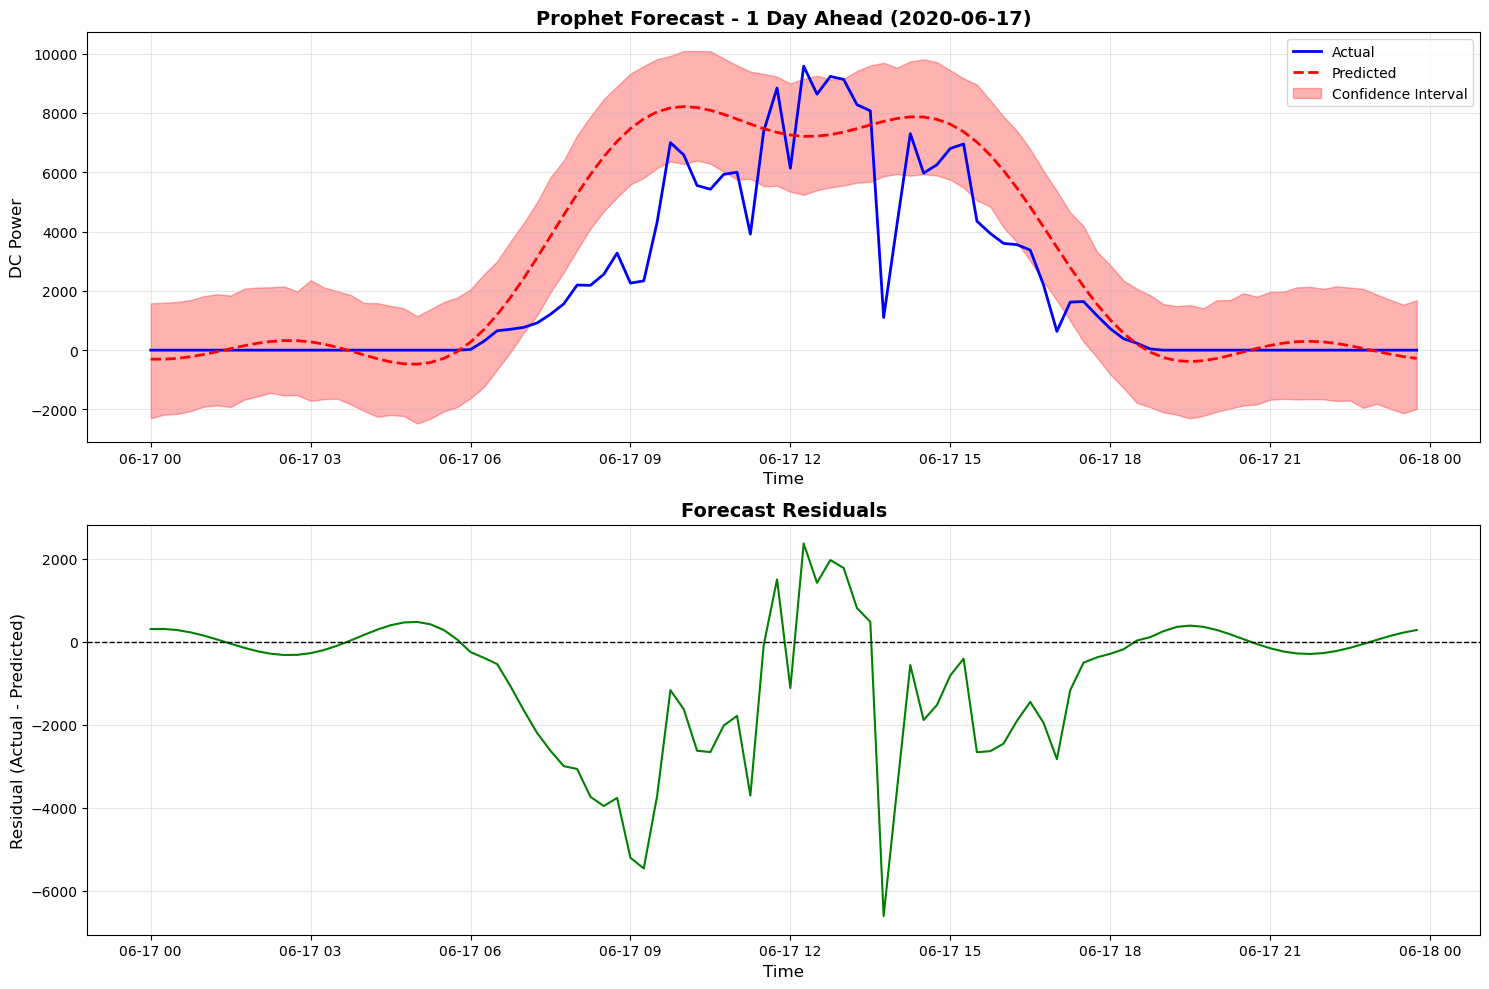

Mean Residual: -814.79
Std Residual: 1621.83


In [8]:
# Visualize test results
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Actual vs Predicted
axes[0].plot(test_predictions['ds'], test_predictions['y'], 'b-', label='Actual', linewidth=2)
axes[0].plot(test_predictions['ds'], test_predictions['yhat'], 'r--', label='Predicted', linewidth=2)
axes[0].fill_between(test_predictions['ds'], 
                      test_predictions['yhat_lower'], 
                      test_predictions['yhat_upper'], 
                      alpha=0.3, color='red', label='Confidence Interval')
axes[0].set_title(f'Prophet Forecast - 1 Day Ahead ({test_day})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('DC Power', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = test_predictions['y'] - test_predictions['yhat']
axes[1].plot(test_predictions['ds'], residuals, 'g-', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Forecast Residuals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Std Residual: {residuals.std():.2f}")

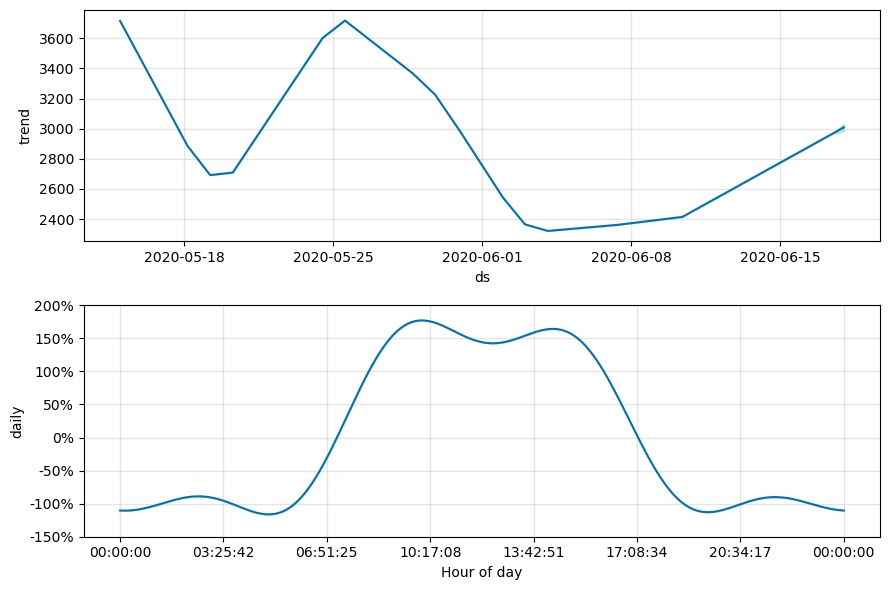

In [9]:
# Additional visualization: Prophet components
fig = model.plot_components(forecast)
plt.tight_layout()
plt.show()

The most important feature of prophet is the possibility to engage human in the loop.

In this way, business people who don't know how to code can improve the forecast with their important business knowledge.

For example, what do notice in this plot?

In [10]:
# Train Prophet model with more rigid trend
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.001  # Lower value = more rigid trend (default is 0.05)
)

# Add custom daily seasonality with higher Fourier order for more flexibility
model.add_seasonality(
    name='daily_enhanced',
    period=1,  # 1 day
    fourier_order=15,  # Higher order = more flexible (default is 3-5)
    prior_scale=10.0   # Higher scale = more flexible seasonality
)

print("Training Prophet model...")
model.fit(train_data)
print("Model training completed!")

17:36:07 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet model...


17:36:07 - cmdstanpy - INFO - Chain [1] done processing


Model training completed!


In [11]:
# Make predictions for the test day (1 day ahead) with floor constraint
future = model.make_future_dataframe(periods=len(test_data), freq='15min')
forecast = model.predict(future)

# Clip negative predictions to 0
forecast['yhat'] = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

# Extract predictions for the test day
test_predictions = forecast[forecast['ds'].dt.date == test_day][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
test_predictions = test_predictions.merge(test_data, on='ds', how='inner')


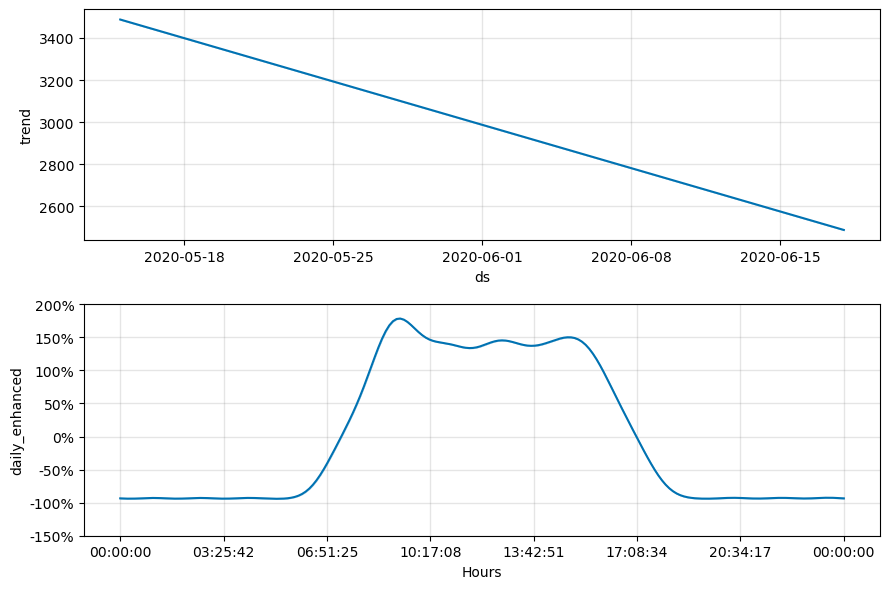

In [12]:
# Plot components
fig = model.plot_components(forecast)
plt.tight_layout()
plt.show()

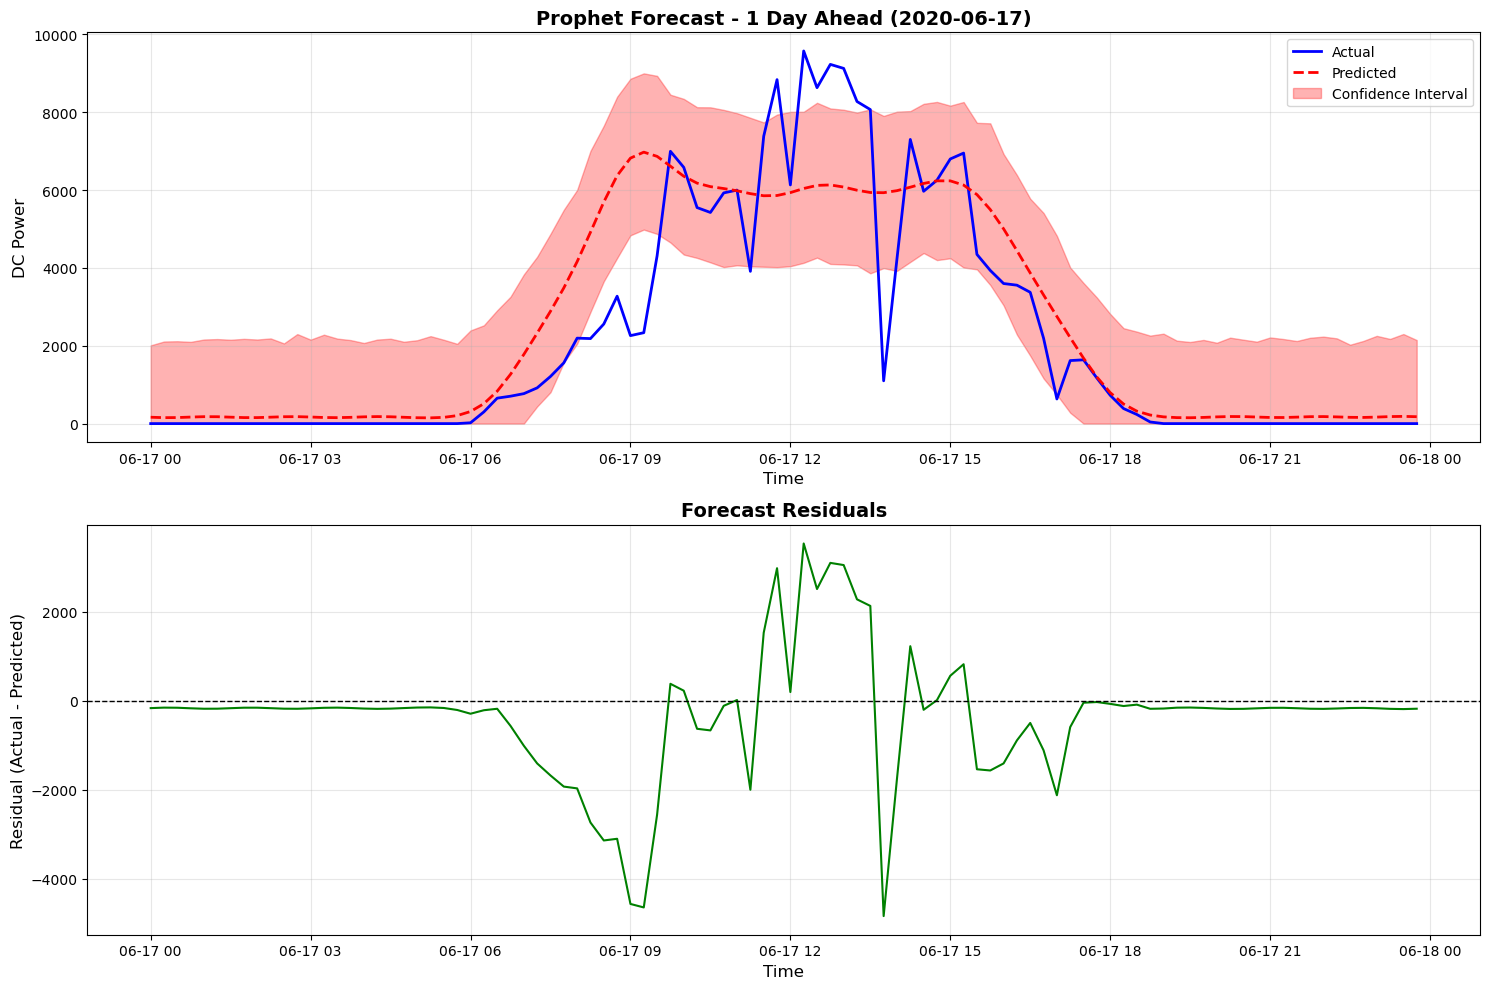

Mean Residual: -345.33
Std Residual: 1399.21


In [13]:
# Visualize backtest results
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Actual vs Predicted
axes[0].plot(test_predictions['ds'], test_predictions['y'], 'b-', label='Actual', linewidth=2)
axes[0].plot(test_predictions['ds'], test_predictions['yhat'], 'r--', label='Predicted', linewidth=2)
axes[0].fill_between(test_predictions['ds'], 
                      test_predictions['yhat_lower'], 
                      test_predictions['yhat_upper'], 
                      alpha=0.3, color='red', label='Confidence Interval')
axes[0].set_title(f'Prophet Forecast - 1 Day Ahead ({test_day})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('DC Power', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = test_predictions['y'] - test_predictions['yhat']
axes[1].plot(test_predictions['ds'], residuals, 'g-', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Forecast Residuals', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Std Residual: {residuals.std():.2f}")

In [14]:
print("=" * 50)
print("FIRST MODEL RESULTS - 1 DAY AHEAD FORECAST")
print("=" * 50)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(" " * 50)

# Evaluate test performance
mae = mean_absolute_error(test_predictions['y'], test_predictions['yhat'])
rmse = np.sqrt(mean_squared_error(test_predictions['y'], test_predictions['yhat']))
r2 = r2_score(test_predictions['y'], test_predictions['yhat'])

# Calculate MAPE (Mean Absolute Percentage Error)
# Only for non-zero actual values to avoid division by zero
non_zero_mask = test_predictions['y'] > 0
mape = np.mean(np.abs((test_predictions.loc[non_zero_mask, 'y'] - test_predictions.loc[non_zero_mask, 'yhat']) / 
                       test_predictions.loc[non_zero_mask, 'y'])) * 100

print("=" * 50)
print("NEW MODEL RESULTS - 1 DAY AHEAD FORECAST")
print("=" * 50)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print("=" * 50)

FIRST MODEL RESULTS - 1 DAY AHEAD FORECAST
Mean Absolute Error (MAE): 1165.41
Root Mean Squared Error (RMSE): 1807.44
R² Score: 0.6172
Mean Absolute Percentage Error (MAPE): 117.30%
                                                  
NEW MODEL RESULTS - 1 DAY AHEAD FORECAST
Mean Absolute Error (MAE): 856.99
Root Mean Squared Error (RMSE): 1434.10
R² Score: 0.7590
Mean Absolute Percentage Error (MAPE): 95.12%


In [15]:
# Merge weather data with time series data
print("Merging weather data with generation data...")

# Aggregate weather data by DATE_TIME (mean across sensors)
weather_agg = weather_df.groupby('DATE_TIME').agg({
    'IRRADIATION': 'mean',
    'AMBIENT_TEMPERATURE': 'mean',
    'MODULE_TEMPERATURE': 'mean'
}).reset_index()

# Merge with time series data
ts_data_with_weather = ts_data.merge(weather_agg, left_on='ds', right_on='DATE_TIME', how='inner')
ts_data_with_weather = ts_data_with_weather.drop('DATE_TIME', axis=1)

print(f"Merged data shape: {ts_data_with_weather.shape}")
print(f"\nMerged data columns: {list(ts_data_with_weather.columns)}")

Merging weather data with generation data...
Merged data shape: (3259, 5)

Merged data columns: ['ds', 'y', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']


In [16]:
# Split the data
train_data = ts_data_with_weather[ts_data_with_weather['ds'].dt.date.isin(train_days)]
test_data = ts_data_with_weather[ts_data_with_weather['ds'].dt.date == test_day]

In [17]:
# Train Prophet model with IRRADIATION as external regressor
model_with_weather = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.001  # Lower value = more rigid trend
)

# Add enhanced daily seasonality
model_with_weather.add_seasonality(
    name='daily_enhanced',
    period=1,  # 1 day
    fourier_order=15,  # Higher order = more flexible
    prior_scale=10.0   # Higher scale = more flexible seasonality
)

# Add IRRADIATION as external regressor
model_with_weather.add_regressor('IRRADIATION', prior_scale=0.05)

print("Training Prophet model with IRRADIATION regressor...")
model_with_weather.fit(train_data)
print("Model training completed!")

Training Prophet model with IRRADIATION regressor...


17:36:46 - cmdstanpy - INFO - Chain [1] start processing
17:36:47 - cmdstanpy - INFO - Chain [1] done processing


Model training completed!


In [18]:
# Make predictions with weather data
future_weather = model_with_weather.make_future_dataframe(periods=len(test_data), freq='15min')

# Add IRRADIATION values to future dataframe
# For the training period, use actual values
train_irradiation = train_data[['ds', 'IRRADIATION']].set_index('ds')
test_irradiation = test_data[['ds', 'IRRADIATION']].set_index('ds')

# Merge irradiation data
future_weather = future_weather.set_index('ds')
future_weather['IRRADIATION'] = pd.concat([train_irradiation, test_irradiation])['IRRADIATION']
future_weather = future_weather.reset_index()

print(f"Future dataframe with IRRADIATION: {future_weather.shape}")
print(f"Missing IRRADIATION values: {future_weather['IRRADIATION'].isnull().sum()}")

# Make forecast
forecast_weather = model_with_weather.predict(future_weather)

# Clip negative predictions to 0
forecast_weather['yhat'] = forecast_weather['yhat'].clip(lower=0)
forecast_weather['yhat_lower'] = forecast_weather['yhat_lower'].clip(lower=0)
forecast_weather['yhat_upper'] = forecast_weather['yhat_upper'].clip(lower=0)

# Extract predictions for the test day
test_predictions_weather = forecast_weather[forecast_weather['ds'].dt.date == test_day][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
test_predictions_weather = test_predictions_weather.merge(test_data, on='ds', how='inner')

print(f"Weather-enhanced predictions generated: {len(test_predictions_weather)} records")
print(f"\nSample predictions:")
print(test_predictions_weather[['ds', 'y', 'yhat', 'IRRADIATION']].head())

Future dataframe with IRRADIATION: (3259, 2)
Missing IRRADIATION values: 0
Weather-enhanced predictions generated: 96 records

Sample predictions:
                   ds    y        yhat  IRRADIATION
0 2020-06-17 00:00:00  0.0  116.378950     0.000024
1 2020-06-17 00:15:00  0.0  109.018832     0.000000
2 2020-06-17 00:30:00  0.0  116.020602     0.000000
3 2020-06-17 00:45:00  0.0  130.351931     0.000000
4 2020-06-17 01:00:00  0.0  138.609064     0.000000


In [19]:
# Evaluate weather-enhanced model performance
mae_weather = mean_absolute_error(test_predictions_weather['y'], test_predictions_weather['yhat'])
rmse_weather = np.sqrt(mean_squared_error(test_predictions_weather['y'], test_predictions_weather['yhat']))
r2_weather = r2_score(test_predictions_weather['y'], test_predictions_weather['yhat'])

# Calculate MAPE for weather model
non_zero_mask_weather = test_predictions_weather['y'] > 0
mape_weather = np.mean(np.abs((test_predictions_weather.loc[non_zero_mask_weather, 'y'] - 
                               test_predictions_weather.loc[non_zero_mask_weather, 'yhat']) / 
                              test_predictions_weather.loc[non_zero_mask_weather, 'y'])) * 100

print("=" * 60)
print("MODEL COMPARISON - 1 DAY AHEAD FORECAST")
print("=" * 60)
print("WITHOUT WEATHER DATA:")
print(f"  MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
print("")
print("WITH IRRADIATION REGRESSOR:")
print(f"  MAE: {mae_weather:.2f} | RMSE: {rmse_weather:.2f} | R²: {r2_weather:.4f} | MAPE: {mape_weather:.2f}%")
print("")
print("IMPROVEMENT:")
print(f"  MAE: {((mae - mae_weather) / mae * 100):+.1f}%")
print(f"  RMSE: {((rmse - rmse_weather) / rmse * 100):+.1f}%")
print(f"  R²: {((r2_weather - r2) / r2 * 100):+.1f}%")
print(f"  MAPE: {((mape - mape_weather) / mape * 100):+.1f}%")
print("=" * 60)

MODEL COMPARISON - 1 DAY AHEAD FORECAST
WITHOUT WEATHER DATA:
  MAE: 856.99 | RMSE: 1434.10 | R²: 0.7590 | MAPE: 95.12%

WITH IRRADIATION REGRESSOR:
  MAE: 830.08 | RMSE: 1390.53 | R²: 0.7734 | MAPE: 73.92%

IMPROVEMENT:
  MAE: +3.1%
  RMSE: +3.0%
  R²: +1.9%
  MAPE: +22.3%


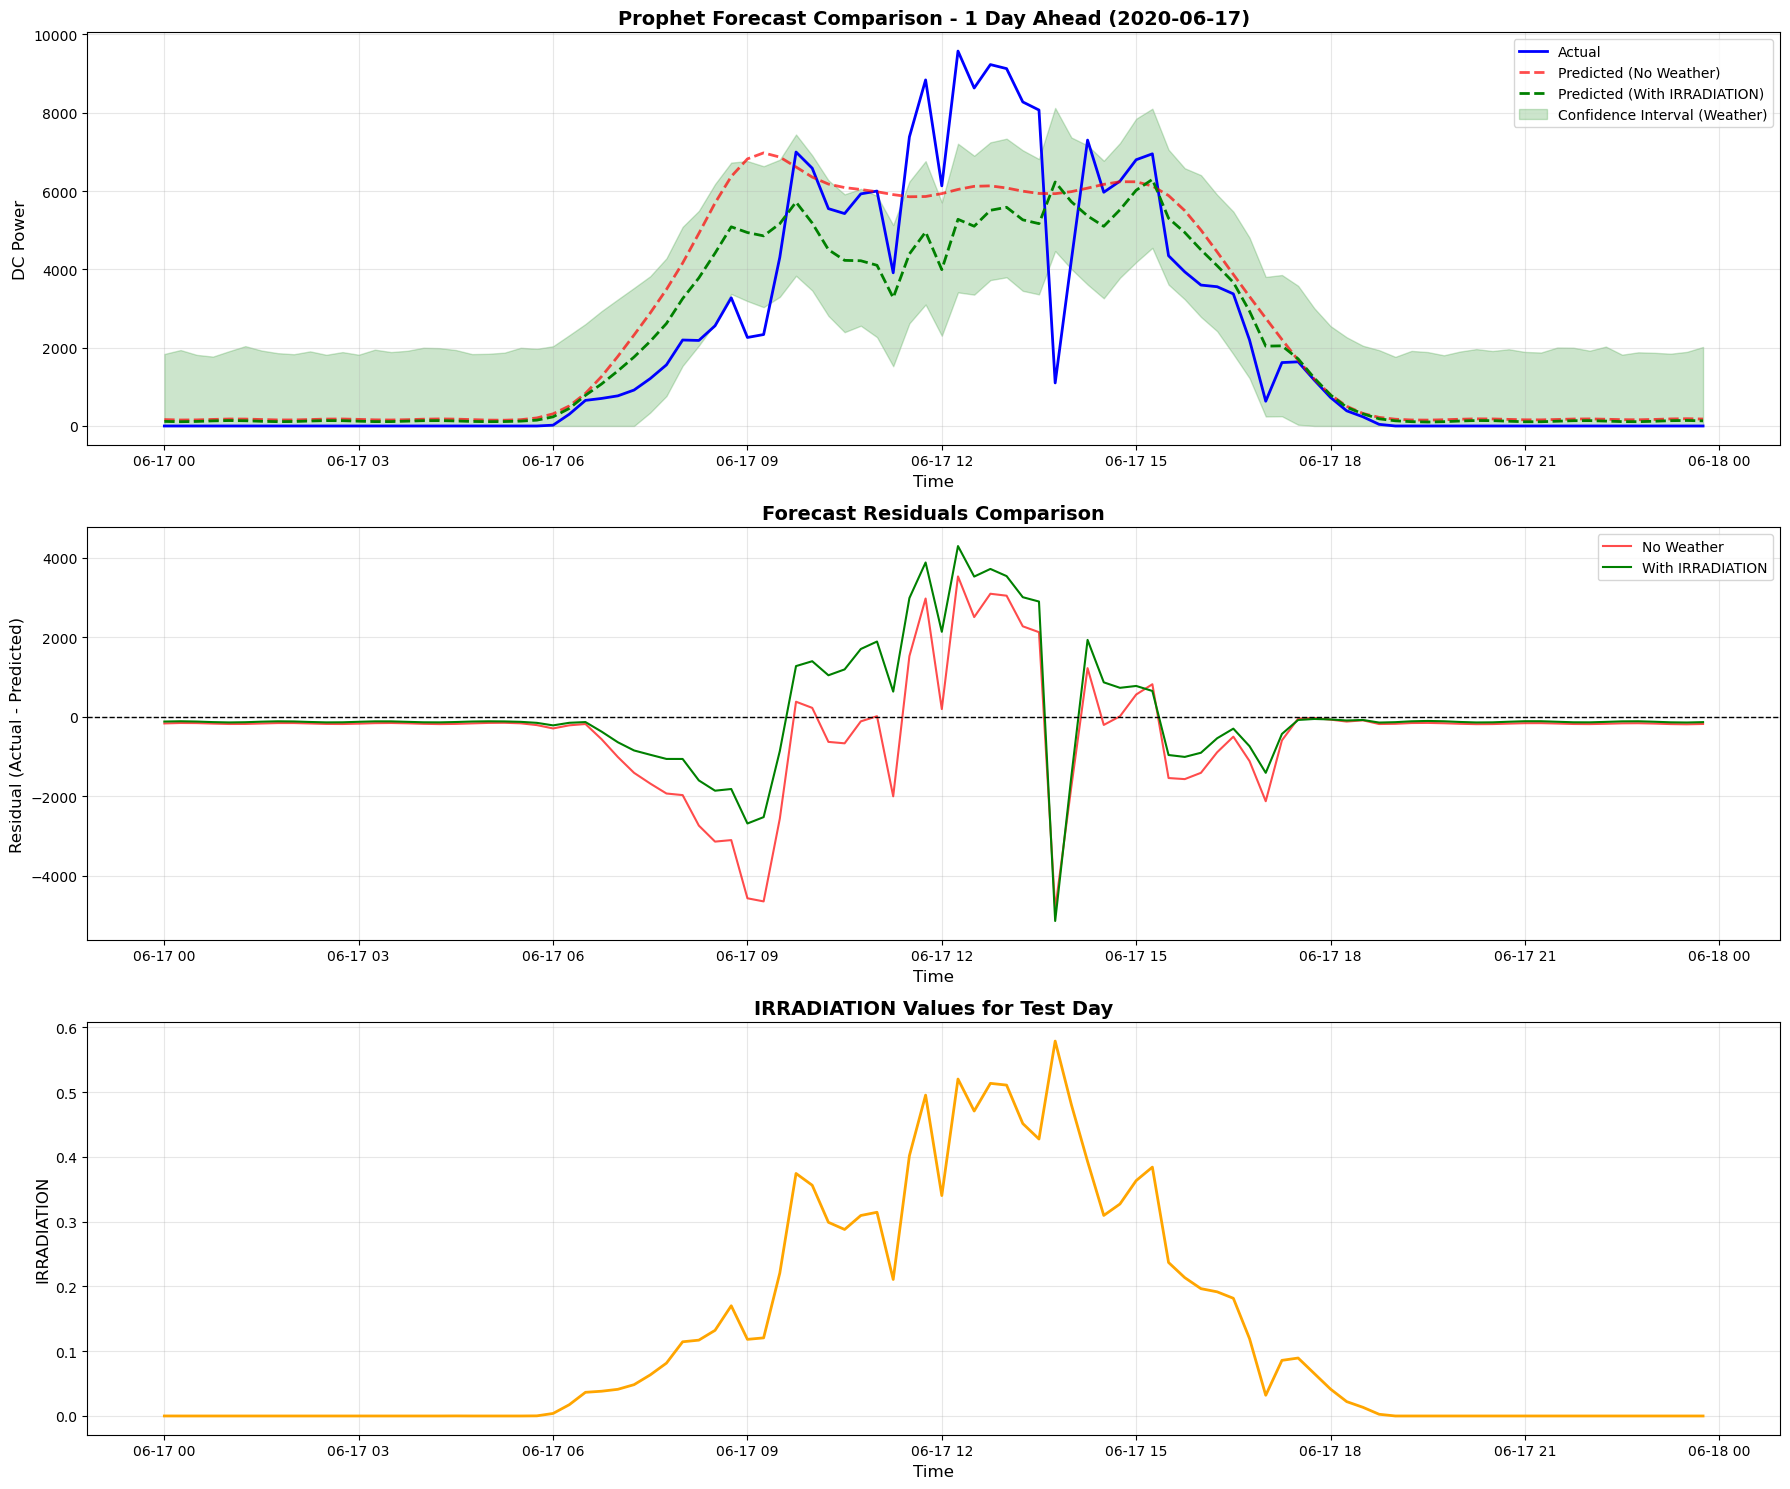


Residuals Statistics Comparison:
No Weather    - Mean: -345.33, Std: 1399.21
With Weather  - Mean: 89.68, Std: 1394.92


In [20]:
# Visualize weather-enhanced model results
fig, axes = plt.subplots(3, 1, figsize=(18, 15))

# Plot 1: Actual vs Predicted (both models)
axes[0].plot(test_predictions['ds'], test_predictions['y'], 'b-', label='Actual', linewidth=2)
axes[0].plot(test_predictions['ds'], test_predictions['yhat'], 'r--', label='Predicted (No Weather)', linewidth=2, alpha=0.7)
axes[0].plot(test_predictions_weather['ds'], test_predictions_weather['yhat'], 'g--', label='Predicted (With IRRADIATION)', linewidth=2)
axes[0].fill_between(test_predictions_weather['ds'], 
                      test_predictions_weather['yhat_lower'], 
                      test_predictions_weather['yhat_upper'], 
                      alpha=0.2, color='green', label='Confidence Interval (Weather)')
axes[0].set_title(f'Prophet Forecast Comparison - 1 Day Ahead ({test_day})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('DC Power', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals comparison
residuals_no_weather = test_predictions['y'] - test_predictions['yhat']
residuals_with_weather = test_predictions_weather['y'] - test_predictions_weather['yhat']

axes[1].plot(test_predictions['ds'], residuals_no_weather, 'r-', linewidth=1.5, alpha=0.7, label='No Weather')
axes[1].plot(test_predictions_weather['ds'], residuals_with_weather, 'g-', linewidth=1.5, label='With IRRADIATION')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Forecast Residuals Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Plot 3: IRRADIATION values
axes[2].plot(test_data['ds'], test_data['IRRADIATION'], 'orange', linewidth=2)
axes[2].set_title('IRRADIATION Values for Test Day', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_ylabel('IRRADIATION', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResiduals Statistics Comparison:")
print(f"No Weather    - Mean: {residuals_no_weather.mean():.2f}, Std: {residuals_no_weather.std():.2f}")
print(f"With Weather  - Mean: {residuals_with_weather.mean():.2f}, Std: {residuals_with_weather.std():.2f}")

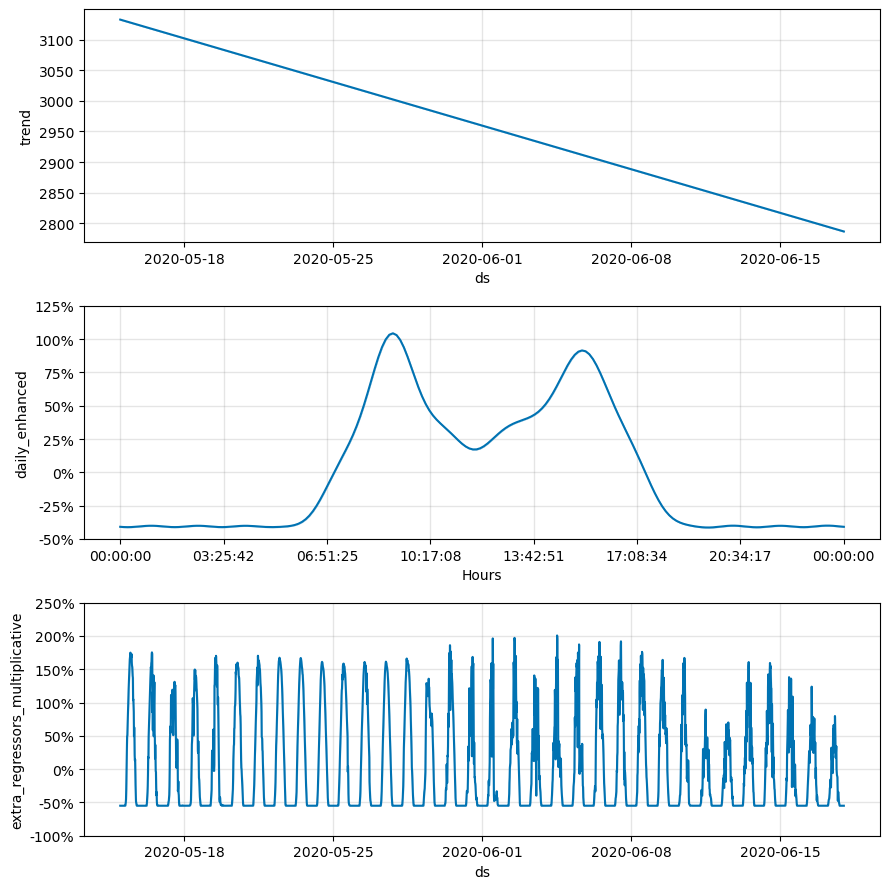

Weather-Enhanced Prophet Components:
  - Trend: Overall time trend
  - daily_enhanced: Enhanced daily seasonality pattern
  - extra_regressors_additive: IRRADIATION regressor contribution


In [21]:
# Plot components of weather-enhanced model
fig = model_with_weather.plot_components(forecast_weather)
plt.tight_layout()
plt.show()

print("Weather-Enhanced Prophet Components:")
print("  - Trend: Overall time trend")
print("  - daily_enhanced: Enhanced daily seasonality pattern")
print("  - extra_regressors_additive: IRRADIATION regressor contribution")

## Step 4: Rolling Backtest - Last 10 Days

Now we'll perform a proper backtesting procedure by forecasting each of the last 10 days, using all previous data for training.

In [22]:
def backtest_prophet_rolling(ts_data, n_test_days=7):
    """
    Perform rolling backtest for Prophet model with IRRADIATION regressor.
    
    Parameters:
    -----------
    ts_data : pd.DataFrame
        Time series data with 'ds', 'y', and 'IRRADIATION' columns
    n_test_days : int
        Number of days to use for backtesting
    
    Returns:
    --------
    results : dict
        Dictionary containing predictions, actuals, and metrics for each test day
    """
    unique_days = sorted(ts_data['ds'].dt.date.unique())
    
    # Get the last n_test_days
    test_days = unique_days[-n_test_days:]
    
    print(f"Starting rolling backtest for {n_test_days} days...")
    print(f"Test period: {test_days[0]} to {test_days[-1]}")
    print("=" * 60)
    
    all_predictions = []
    all_actuals = []
    daily_metrics = []
    
    for i, test_day in enumerate(test_days, 1):
        print(f"\n[Day {i}/{n_test_days}] Testing: {test_day}")
        
        # Split data: all days before test_day for training
        train_data = ts_data[ts_data['ds'].dt.date < test_day]
        test_data = ts_data[ts_data['ds'].dt.date == test_day]
        
        if len(test_data) == 0:
            print(f"  ⚠ No data available for {test_day}, skipping...")
            continue
        
        print(f"  Training samples: {len(train_data)} | Test samples: {len(test_data)}")
        
        # Train Prophet model with IRRADIATION as external regressor
        model = Prophet(
            daily_seasonality=False,
            weekly_seasonality=False,
            yearly_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.001  # Lower value = more rigid trend
        )

        # Add enhanced daily seasonality
        model.add_seasonality(
            name='daily_enhanced',
            period=1,  # 1 day
            fourier_order=15,  # Higher order = more flexible
            prior_scale=10.0   # Higher scale = more flexible seasonality
        )

        # Add IRRADIATION as external regressor
        model.add_regressor('IRRADIATION', prior_scale=0.8)

        model.fit(train_data)

        # Make prediction for test day - IMPORTANT: Add IRRADIATION data
        future = model.make_future_dataframe(periods=len(test_data), freq='15min')
        
        # Add IRRADIATION values to future dataframe
        # For training period, use actual values from train_data
        # For test period, use actual values from test_data
        train_irradiation = train_data[['ds', 'IRRADIATION']].set_index('ds')
        test_irradiation = test_data[['ds', 'IRRADIATION']].set_index('ds')
        
        # Merge irradiation data with future dataframe
        future = future.set_index('ds')
        future['IRRADIATION'] = pd.concat([train_irradiation, test_irradiation])['IRRADIATION']
        future = future.reset_index()
        
        # Check for missing IRRADIATION values
        missing_irradiation = future['IRRADIATION'].isnull().sum()
        if missing_irradiation > 0:
            print(f"  ⚠ Warning: {missing_irradiation} missing IRRADIATION values")
        
        # Make forecast
        forecast = model.predict(future)
        
        # Clip negative predictions to 0
        forecast['yhat'] = forecast['yhat'].clip(lower=0)
        forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
        forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)
        
        # Extract predictions for test day
        day_predictions = forecast[forecast['ds'].dt.date == test_day][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
        day_predictions = day_predictions.merge(test_data, on='ds', how='inner')
        
        # Calculate metrics for this day
        mae = mean_absolute_error(day_predictions['y'], day_predictions['yhat'])
        rmse = np.sqrt(mean_squared_error(day_predictions['y'], day_predictions['yhat']))
        r2 = r2_score(day_predictions['y'], day_predictions['yhat'])
        
        # MAPE only for non-zero values
        non_zero_mask = day_predictions['y'] > 0
        if non_zero_mask.sum() > 0:
            mape = np.mean(np.abs((day_predictions.loc[non_zero_mask, 'y'] - 
                                   day_predictions.loc[non_zero_mask, 'yhat']) / 
                                  day_predictions.loc[non_zero_mask, 'y'])) * 100
        else:
            mape = np.nan
        
        print(f"  MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
        
        # Store results
        all_predictions.append(day_predictions)
        daily_metrics.append({
            'test_day': test_day,
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'mape': mape,
            'n_samples': len(day_predictions)
        })
    
    # Combine all predictions
    combined_predictions = pd.concat(all_predictions, ignore_index=True)
    metrics_df = pd.DataFrame(daily_metrics)
    
    print("\n" + "=" * 60)
    print("✓ Backtesting completed!")
    print("=" * 60)
    
    return {
        'predictions': combined_predictions,
        'daily_metrics': metrics_df,
        'test_days': test_days
    }

# Run the rolling backtest with weather data
backtest_results = backtest_prophet_rolling(ts_data_with_weather, n_test_days=7)

Starting rolling backtest for 7 days...
Test period: 2020-06-11 to 2020-06-17

[Day 1/7] Testing: 2020-06-11
  Training samples: 2587 | Test samples: 96


17:37:30 - cmdstanpy - INFO - Chain [1] start processing
17:37:30 - cmdstanpy - INFO - Chain [1] done processing


  MAE: 759.25 | RMSE: 1404.50 | R²: 0.7234 | MAPE: 79.10%

[Day 2/7] Testing: 2020-06-12
  Training samples: 2683 | Test samples: 96


17:37:31 - cmdstanpy - INFO - Chain [1] start processing
17:37:31 - cmdstanpy - INFO - Chain [1] done processing


  MAE: 734.43 | RMSE: 1452.15 | R²: 0.7652 | MAPE: 41.89%

[Day 3/7] Testing: 2020-06-13
  Training samples: 2779 | Test samples: 96


...

  MAE: 425.42 | RMSE: 736.89 | R²: 0.9443 | MAPE: 20.86%

[Day 6/7] Testing: 2020-06-16
  Training samples: 3067 | Test samples: 96


17:37:34 - cmdstanpy - INFO - Chain [1] start processing
17:37:35 - cmdstanpy - INFO - Chain [1] done processing


  MAE: 910.45 | RMSE: 1874.21 | R²: 0.7296 | MAPE: 28.19%

[Day 7/7] Testing: 2020-06-17
  Training samples: 3163 | Test samples: 96


17:37:35 - cmdstanpy - INFO - Chain [1] start processing
17:37:36 - cmdstanpy - INFO - Chain [1] done processing


  MAE: 778.05 | RMSE: 1407.56 | R²: 0.7678 | MAPE: 55.48%

✓ Backtesting completed!


In [23]:
# Display overall backtest metrics
daily_metrics = backtest_results['daily_metrics']

print("=" * 60)
print("OVERALL BACKTEST METRICS (7-DAY ROLLING FORECAST)")
print("=" * 60)
print(f"Average MAE:  {daily_metrics['mae'].mean():.2f} ± {daily_metrics['mae'].std():.2f}")
print(f"Average RMSE: {daily_metrics['rmse'].mean():.2f} ± {daily_metrics['rmse'].std():.2f}")
print(f"Average R²:   {daily_metrics['r2'].mean():.4f} ± {daily_metrics['r2'].std():.4f}")
print(f"Average MAPE: {daily_metrics['mape'].mean():.2f}% ± {daily_metrics['mape'].std():.2f}%")
print("=" * 60)

print("\n📊 Daily Performance Breakdown:")
print(daily_metrics.to_string(index=False))

OVERALL BACKTEST METRICS (7-DAY ROLLING FORECAST)
Average MAE:  790.81 ± 192.65
Average RMSE: 1464.16 ± 377.05
Average R²:   0.7930 ± 0.0750
Average MAPE: 43.65% ± 20.51%

📊 Daily Performance Breakdown:
  test_day         mae        rmse       r2      mape  n_samples
2020-06-11  759.254580 1404.500635 0.723436 79.102287         96
2020-06-12  734.429896 1452.147005 0.765216 41.887489         96
2020-06-13  891.463408 1529.101520 0.811908 53.038636         96
2020-06-14 1036.567003 1844.686557 0.808866 26.967670         96
2020-06-15  425.422901  736.886372 0.944272 20.856722         96
2020-06-16  910.453092 1874.213299 0.729578 28.190587         96
2020-06-17  778.045411 1407.561067 0.767840 55.479974         96


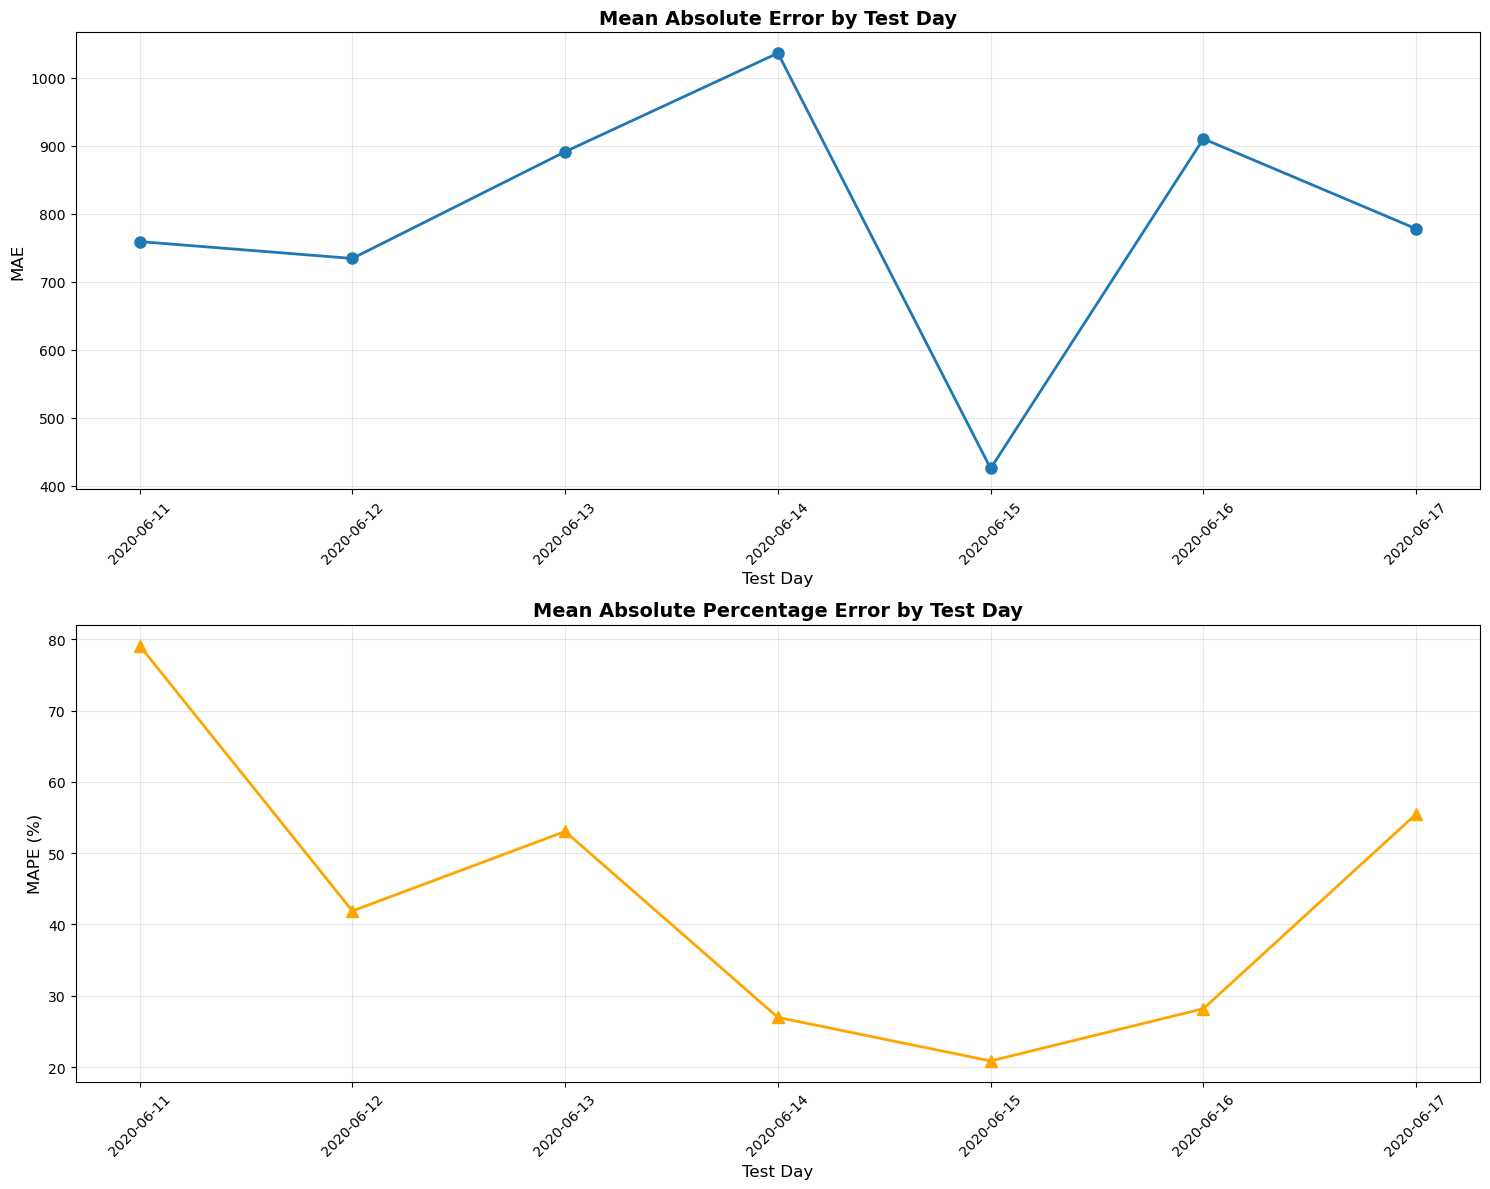

In [24]:
# Visualize backtest performance over time
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Metrics over test days
axes[0].plot(daily_metrics['test_day'], daily_metrics['mae'], 'o-', label='MAE', linewidth=2, markersize=8)
axes[0].set_title('Mean Absolute Error by Test Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Test Day', fontsize=12)
axes[0].set_ylabel('MAE', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: MAPE over test days
axes[1].plot(daily_metrics['test_day'], daily_metrics['mape'], '^-', color='orange', 
             label='MAPE', linewidth=2, markersize=8)
axes[1].set_title('Mean Absolute Percentage Error by Test Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Test Day', fontsize=12)
axes[1].set_ylabel('MAPE (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

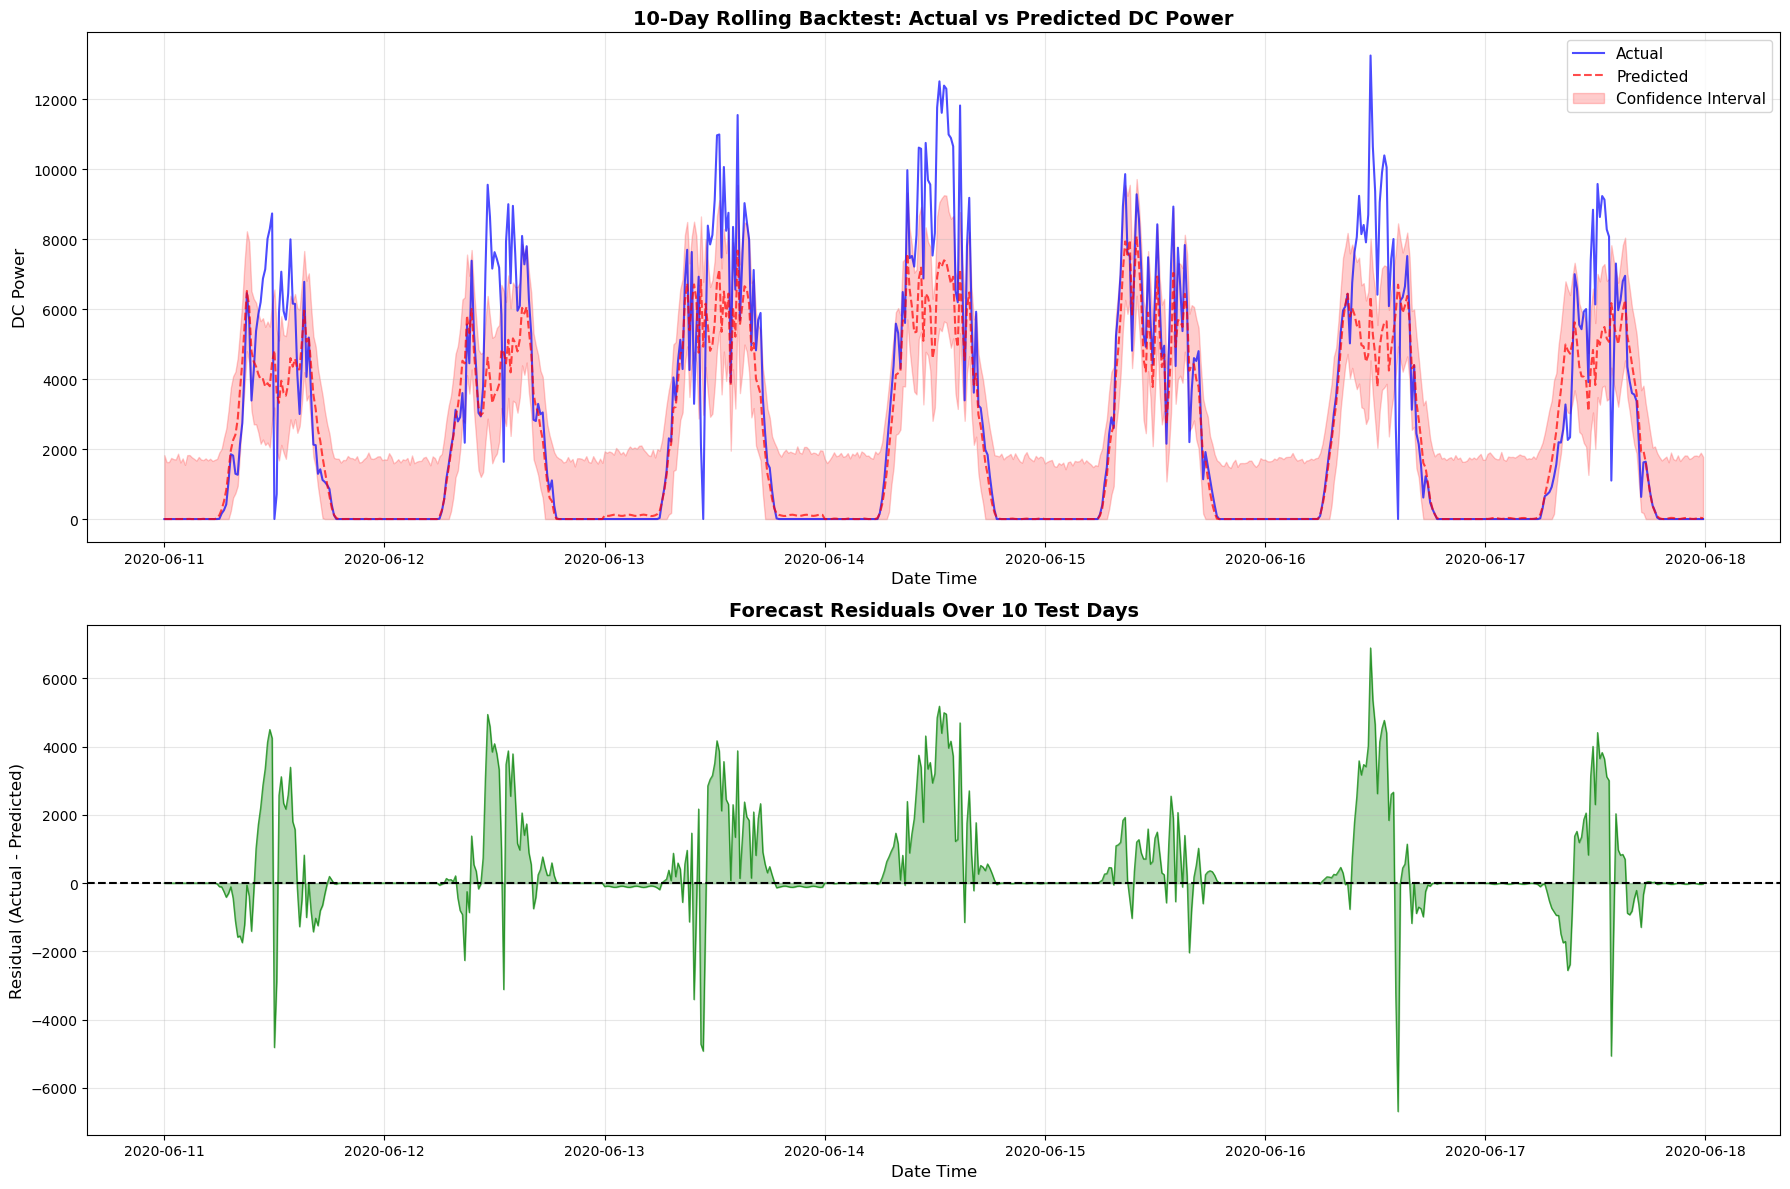


Overall Residuals Statistics:
Mean Residual: 458.36
Std Residual: 1434.78
Min Residual: -6696.77
Max Residual: 6891.51


In [25]:
# Visualize predictions vs actuals for all 10 test days
predictions_df = backtest_results['predictions']

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Plot 1: All predictions vs actuals
axes[0].plot(predictions_df['ds'], predictions_df['y'], 'b-', label='Actual', linewidth=1.5, alpha=0.7)
axes[0].plot(predictions_df['ds'], predictions_df['yhat'], 'r--', label='Predicted', linewidth=1.5, alpha=0.7)
axes[0].fill_between(predictions_df['ds'], 
                      predictions_df['yhat_lower'], 
                      predictions_df['yhat_upper'], 
                      alpha=0.2, color='red', label='Confidence Interval')
axes[0].set_title('10-Day Rolling Backtest: Actual vs Predicted DC Power', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date Time', fontsize=12)
axes[0].set_ylabel('DC Power', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals over time
residuals = predictions_df['y'] - predictions_df['yhat']
axes[1].plot(predictions_df['ds'], residuals, 'g-', linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].fill_between(predictions_df['ds'], residuals, 0, alpha=0.3, color='green')
axes[1].set_title('Forecast Residuals Over 10 Test Days', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date Time', fontsize=12)
axes[1].set_ylabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOverall Residuals Statistics:")
print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Std Residual: {residuals.std():.2f}")
print(f"Min Residual: {residuals.min():.2f}")
print(f"Max Residual: {residuals.max():.2f}")